### Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

df = pd.read_csv('titanic_toy.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values %:")
print((df.isnull().mean() * 100).round(2))

Shape: (891, 4)

First 5 rows:
    Age     Fare  Family  Survived
0  22.0   7.2500       1         0
1  38.0  71.2833       1         1
2  26.0   7.9250       0         1
3  35.0  53.1000       1         1
4  35.0   8.0500       0         0

Missing values %:
Age         19.87
Fare         5.05
Family       0.00
Survived     0.00
dtype: float64


### Train Test Split

In [3]:
X = df.drop(columns=['Survived'])   # features
y = df['Survived']                   # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nMissing in X_train:")
print(X_train.isnull().sum())
print((df.isnull().mean() * 100).round(2))

X_train shape: (712, 3)
X_test shape : (179, 3)

Missing in X_train:
Age       148
Fare       36
Family      0
dtype: int64
Age         19.87
Fare         5.05
Family       0.00
Survived     0.00
dtype: float64


### Applying Arbitrary Imputation - Pandas way

In [4]:
# make a copy to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test  = X_test.copy()

# fill Age missing with 99 (way above max age of ~80)
X_train['Age_99'] = X_train['Age'].fillna(99)

# fill Age missing with -1 (negative → impossible age)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

# fill Fare missing with 999 (way above typical fare)
X_train['Fare_999'] = X_train['Fare'].fillna(999)

# fill Fare missing with -1 (negative → impossible fare)
X_train['Fare_minus1']= X_train['Fare'].fillna(-1)

print("After imputation sample:")
print(X_train[['Age','Age_99','Age_minus1',
               'Fare','Fare_999','Fare_minus1']].head(10))

After imputation sample:
      Age  Age_99  Age_minus1     Fare  Fare_999  Fare_minus1
30   40.0    40.0        40.0  27.7208   27.7208      27.7208
10    4.0     4.0         4.0  16.7000   16.7000      16.7000
873  47.0    47.0        47.0   9.0000    9.0000       9.0000
182   9.0     9.0         9.0  31.3875   31.3875      31.3875
876  20.0    20.0        20.0   9.8458    9.8458       9.8458
213  30.0    30.0        30.0  13.0000   13.0000      13.0000
157  30.0    30.0        30.0   8.0500    8.0500       8.0500
780  13.0    13.0        13.0   7.2292    7.2292       7.2292
572  36.0    36.0        36.0  26.3875   26.3875      26.3875
77    NaN    99.0        -1.0   8.0500    8.0500       8.0500


### Check variance

In [5]:
print(f"\nAge original variance  : {X_train['Age'].var():.2f}")
print(f"Age with 99 variance   : {X_train['Age_99'].var():.2f}")
print(f"Age with -1 variance   : {X_train['Age_minus1'].var():.2f}")

age_orig = X_train['Age'].var()
print(f"\n99 inflates variance by : {X_train['Age_99'].var()/age_orig:.1f}x  ❌")
print(f"-1 inflates variance by : {X_train['Age_minus1'].var()/age_orig:.1f}x  ✅")

print(f"\nFare original variance  : {X_train['Fare'].var():.2f}")
print(f"Fare with 999 variance  : {X_train['Fare_999'].var():.2f}")
print(f"Fare with -1 variance   : {X_train['Fare_minus1'].var():.2f}")

fare_orig = X_train['Fare'].var()
print(f"\n999 inflates variance by : {X_train['Fare_999'].var()/fare_orig:.1f}x  ❌")
print(f"-1 inflates variance by  : {X_train['Fare_minus1'].var()/fare_orig:.1f}x  ✅")


Age original variance  : 204.35
Age with 99 variance   : 951.73
Age with -1 variance   : 318.09

99 inflates variance by : 4.7x  ❌
-1 inflates variance by : 1.6x  ✅

Fare original variance  : 2448.20
Fare with 999 variance  : 47219.20
Fare with -1 variance   : 2378.57

999 inflates variance by : 19.3x  ❌
-1 inflates variance by  : 1.0x  ✅


### Visualize Distribution Impact

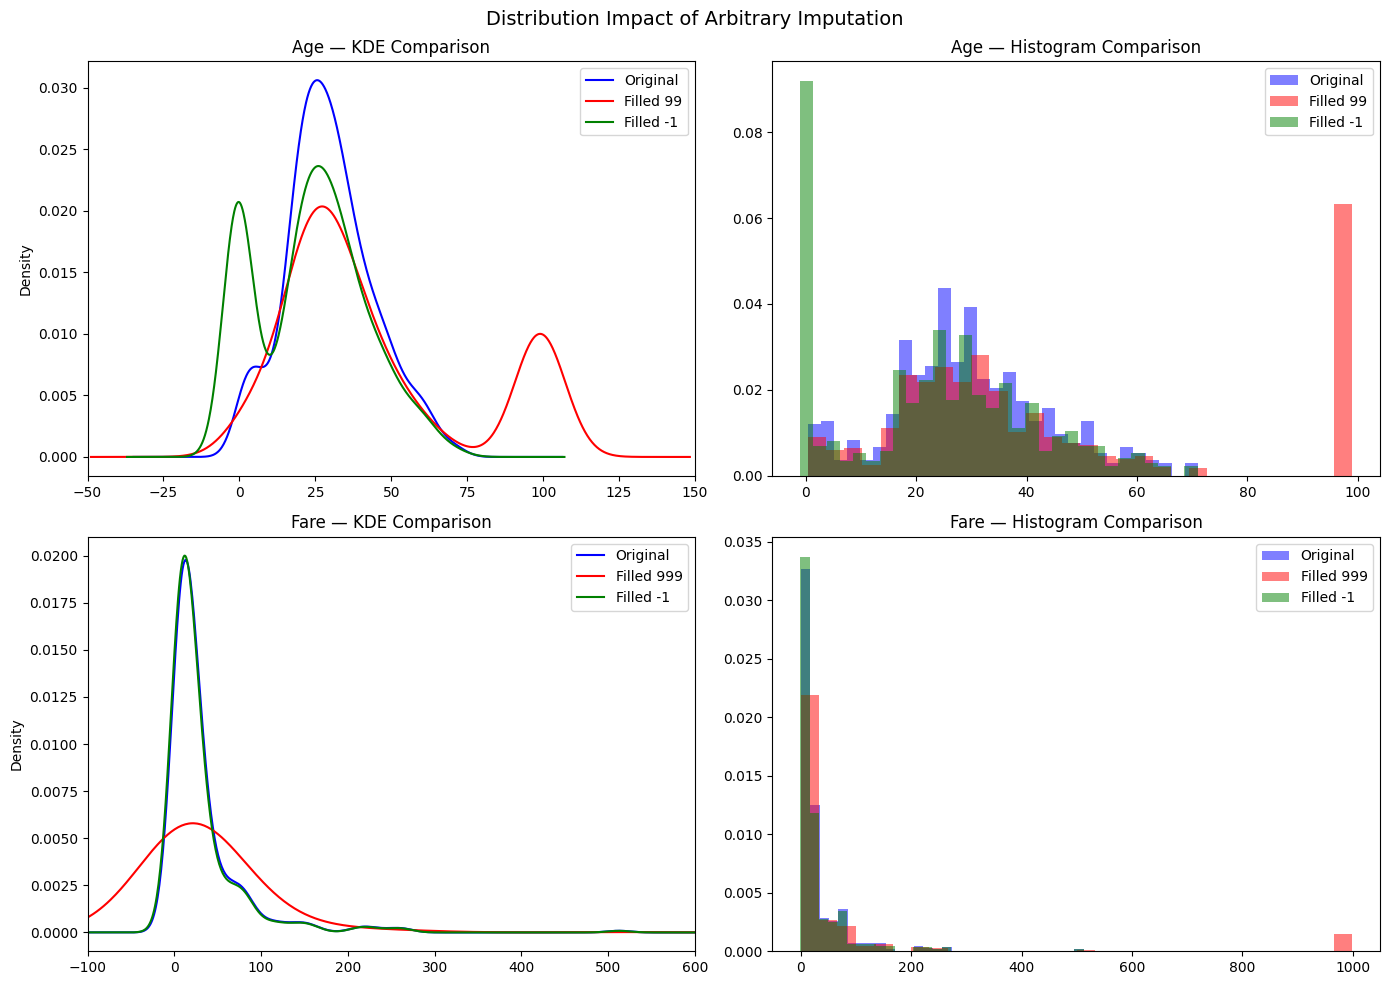

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution Impact of Arbitrary Imputation", fontsize=14)

# Age distributions KDE plot
X_train['Age'].plot.kde(         ax=axes[0][0], color='blue',  label='Original')
X_train['Age_99'].plot.kde(      ax=axes[0][0], color='red',   label='Filled 99')
X_train['Age_minus1'].plot.kde(  ax=axes[0][0], color='green', label='Filled -1')
axes[0][0].set_title("Age — KDE Comparison")
axes[0][0].legend()
axes[0][0].set_xlim(-50, 150)

# Age histogram Plot
axes[0][1].hist(X_train['Age'].dropna(),  bins=30, alpha=0.5,
                color='blue',  label='Original',   density=True)
axes[0][1].hist(X_train['Age_99'],        bins=30, alpha=0.5,
                color='red',   label='Filled 99',  density=True)
axes[0][1].hist(X_train['Age_minus1'],    bins=30, alpha=0.5,
                color='green', label='Filled -1',  density=True)
axes[0][1].set_title("Age — Histogram Comparison")
axes[0][1].legend()

# Fare distributions KDE plot
X_train['Fare'].plot.kde(        ax=axes[1][0], color='blue',  label='Original')
X_train['Fare_999'].plot.kde(    ax=axes[1][0], color='red',   label='Filled 999')
X_train['Fare_minus1'].plot.kde( ax=axes[1][0], color='green', label='Filled -1')
axes[1][0].set_title("Fare — KDE Comparison")
axes[1][0].legend()
axes[1][0].set_xlim(-100, 600)

# Fare histogram Plot
axes[1][1].hist(X_train['Fare'].dropna(), bins=30, alpha=0.5,
                color='blue',  label='Original',    density=True)
axes[1][1].hist(X_train['Fare_999'],      bins=30, alpha=0.5,
                color='red',   label='Filled 999',  density=True)
axes[1][1].hist(X_train['Fare_minus1'],   bins=30, alpha=0.5,
                color='green', label='Filled -1',   density=True)
axes[1][1].set_title("Fare — Histogram Comparison")
axes[1][1].legend()

plt.tight_layout()
plt.show()

### Check Correlation Impact

In [7]:
# correlation matrix shows how imputation changes
# relationships between columns

print("Correlation matrix after imputation:")
print(X_train.corr().round(3))

print("\nKey observations:")
print(f"Age vs Fare (original)    : {X_train['Age'].corr(X_train['Fare']):.3f}")
print(f"Age_99 vs Fare (imputed)  : {X_train['Age_99'].corr(X_train['Fare']):.3f}")
print(f"Age_-1 vs Fare (imputed)  : {X_train['Age_minus1'].corr(X_train['Fare']):.3f}")

Correlation matrix after imputation:
               Age   Fare  Family  Age_99  Age_minus1  Fare_999  Fare_minus1
Age          1.000  0.093  -0.299   1.000       1.000     0.051        0.085
Fare         0.093  1.000   0.208  -0.066       0.142     1.000        1.000
Family      -0.299  0.208   1.000  -0.145      -0.141     0.032        0.205
Age_99       1.000 -0.066  -0.145   1.000      -0.344    -0.024       -0.063
Age_minus1   1.000  0.142  -0.141  -0.344       1.000     0.066        0.132
Fare_999     0.051  1.000   0.032  -0.024       0.066     1.000        0.072
Fare_minus1  0.085  1.000   0.205  -0.063       0.132     0.072        1.000

Key observations:
Age vs Fare (original)    : 0.093
Age_99 vs Fare (imputed)  : -0.066
Age_-1 vs Fare (imputed)  : 0.142
